## Анализ покупательской активности и когортный анализ интернет-магазина

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin-1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [5]:
print(df.shape)

(541909, 8)


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
print("Количество уникальных клиентов:", df['CustomerID'].nunique())
print("Количество уникальных стран:", df['Country'].nunique())
print("Количество уникальных товаров:", df['StockCode'].nunique())
print("Количество уникальных заказов:", df['InvoiceNo'].nunique())

Количество уникальных клиентов: 4372
Количество уникальных стран: 38
Количество уникальных товаров: 4070
Количество уникальных заказов: 25900


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df['Country'].value_counts()

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
                   ...  
Lithuania             35
Brazil                32
Czech Republic        30
Bahrain               19
Saudi Arabia          10
Name: count, Length: 38, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(5268)

## Выводы на основе имеющихся данных
1. **Размер данных:** 541 909 строк, 8 колонок.
2. **Пропуски:**
   - `CustomerID` — 135 080 пропусков (~25% от всех записей). Эти строки бесполезны для когортного анализа, так как клиент неизвестен.
   - `Description` — 1 454 пропуска.
3. **Дубликаты:** 5 268 полных дубликатов строк — их можно удалить без потери информации.
4. **Отрицательные значения:** в колонках `Quantity` и `UnitPrice` встречаются отрицательные значения. Скорее всего, это возвраты или отмены заказов. Для анализа продаж мы их исключим.
5. **Топ-5 стран по числу заказов:** UK, Germany, France, EIRE, Spain. Всего представлено 38 стран.



In [12]:
df = df.drop_duplicates()
print(f"После удаления дубликатов: {df.shape}")

После удаления дубликатов: (536641, 8)


In [13]:
df = df.dropna(subset='CustomerID')
print(f"После удаления пропусков CustomerID: {df.shape}")

После удаления пропусков CustomerID: (401604, 8)


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,401604.000000,401604,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,250.283037,NaN,69.764035,1714.006089


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


In [17]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [18]:
#создание датафрейма где не учитываются возвраты товаров
df_sales = df[(df['Quantity'] > 0)].copy()

In [19]:
print("Размер исходного датафрейма (с возвратами):", df.shape)
print("Размер датафрейма продаж (без возвратов):", df_sales.shape)

Размер исходного датафрейма (с возвратами): (401604, 9)
Размер датафрейма продаж (без возвратов): (392732, 9)


На этапе чистки у нас пропали строки, содержащие отрицательные значения UnitPrice. Так же я разделил данные и для 
анализа продуктовых метрик я создал отдельный датафрейм, в котором не учитываются возвраты товаров, для того чтобы избежать
возможных искажений. Далее под total_revenue для удобства я буду понимать общую валовую выручку без учета возвратов. 

In [20]:
net_revenue = df['Revenue'].sum()
print(f"Общая чистая выручка: {net_revenue:,.2f}") #с учетом вовзратов

Общая чистая выручка: 8,278,519.42


In [21]:
total_revenue = df_sales['Revenue'].sum()

In [22]:
total_orders = df_sales['InvoiceNo'].nunique()

In [23]:
total_customers = df_sales['CustomerID'].nunique()

In [24]:
avg_order_value = total_revenue / total_orders

In [25]:
avg_revenue_per_customer = total_revenue / total_customers

In [26]:
print(f"Общая валовая выручка: {total_revenue:,.2f}")
print(f"Количество заказов: {total_orders}")
print(f"Количество уникальных клиентов: {total_customers}")
print(f"Средний чек: {avg_order_value:.2f}")
print(f"Средняя выручка на клиента: {avg_revenue_per_customer:.2f}")

Общая валовая выручка: 8,887,208.89
Количество заказов: 18536
Количество уникальных клиентов: 4339
Средний чек: 479.46
Средняя выручка на клиента: 2048.22


In [27]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

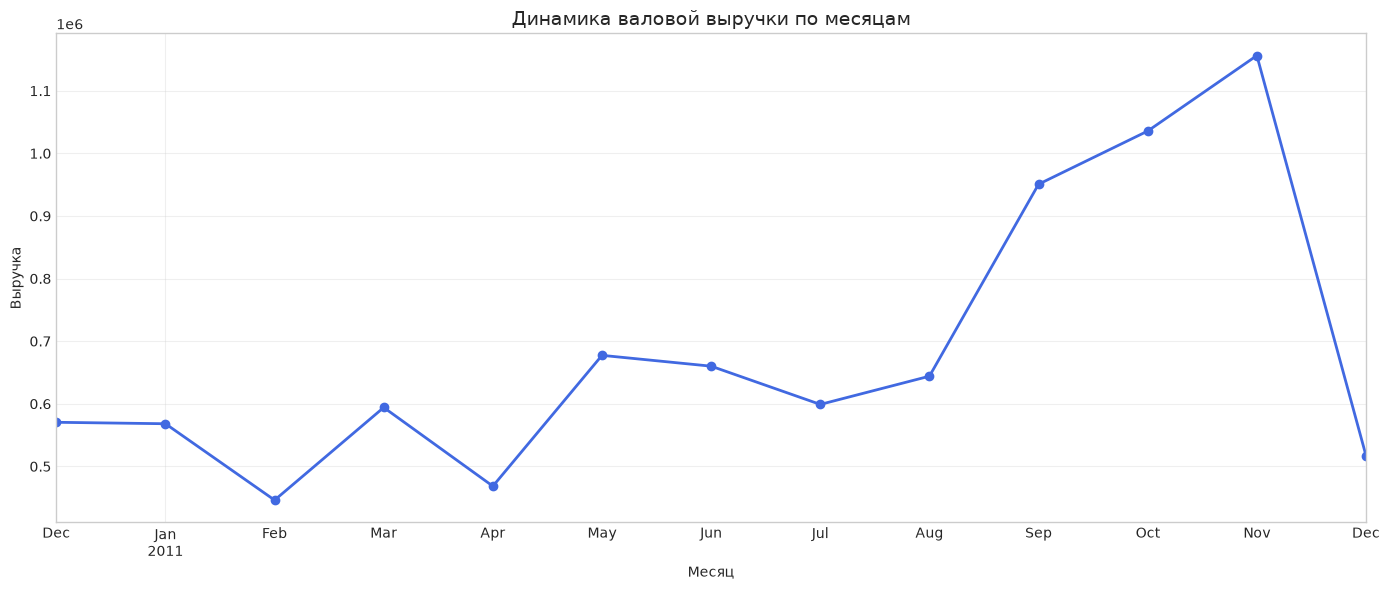

In [28]:
monthly_revenue = df_sales.groupby(df_sales['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()

plt.figure(figsize=(14,6))
monthly_revenue.plot(kind='line', marker='o', linewidth=2, color='royalblue')
plt.title('Динамика валовой выручки по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

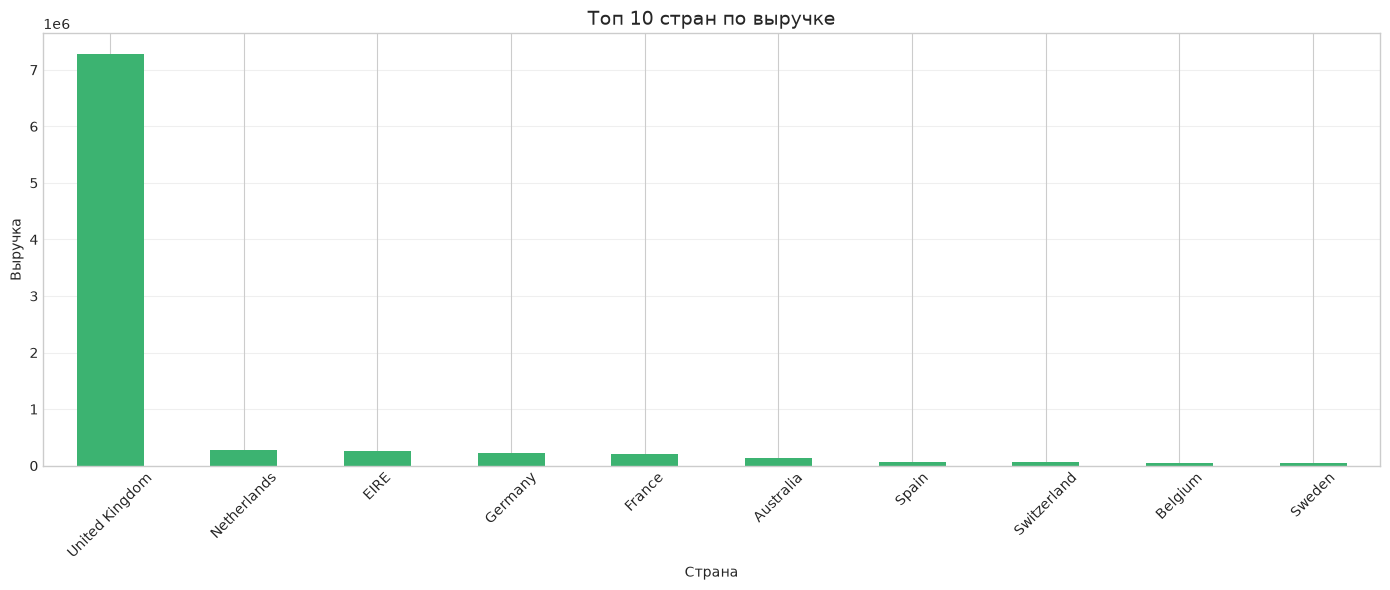

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


In [29]:
country_revenue = df_sales.groupby(df_sales['Country'])['Revenue'].sum().sort_values(ascending=False)

cr_with_uk = country_revenue.head(10)

plt.figure(figsize=(14,6))
cr_with_uk.plot(kind='bar', color='mediumseagreen')
plt.title('Топ 10 стран по выручке', fontsize=14)
plt.xlabel('Страна')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(cr_with_uk)

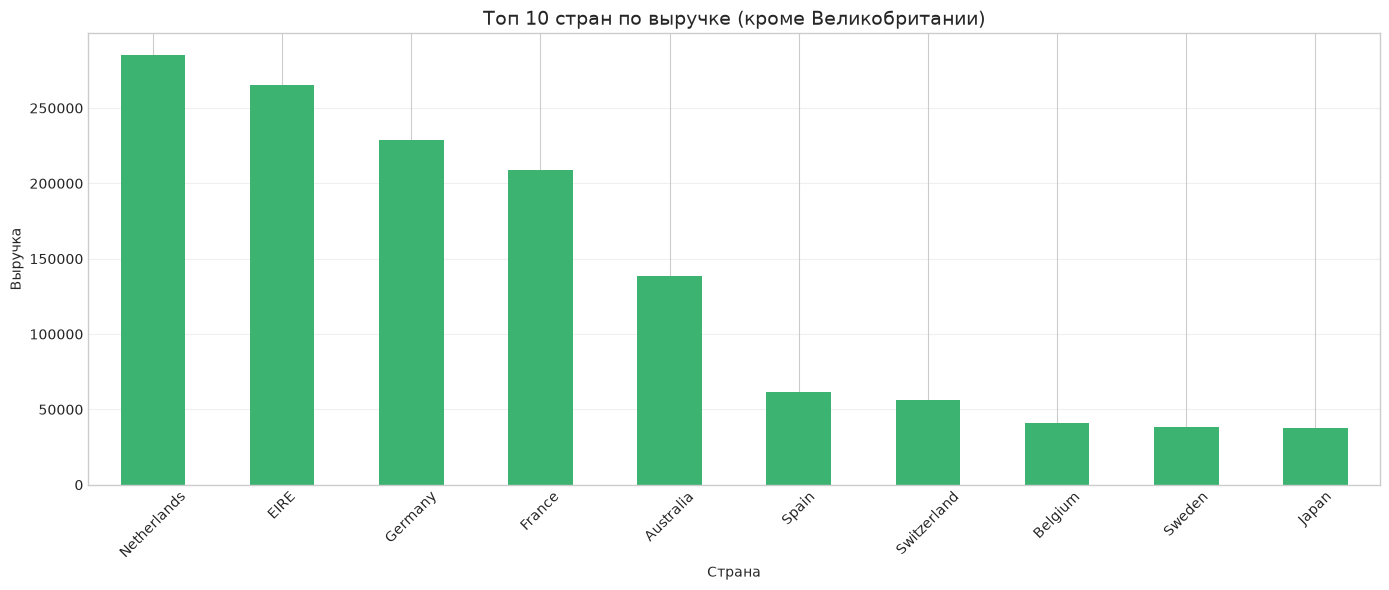

In [30]:
top_other = country_revenue.drop('United Kingdom', errors='ignore').head(10)

plt.figure(figsize=(14,6))
top_other.plot(kind='bar', color='mediumseagreen')
plt.title('Топ 10 стран по выручке (кроме Великобритании)', fontsize=14)
plt.xlabel('Страна')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

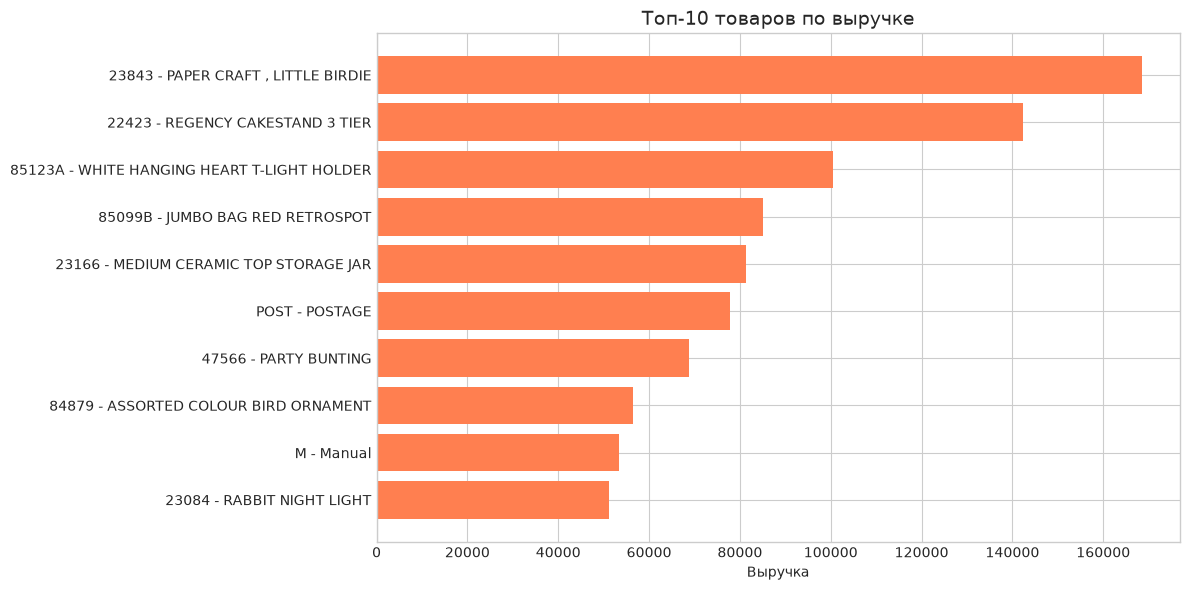

In [31]:
product_revenue = df_sales.groupby(['StockCode', 'Description'])['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()

product_revenue['Label'] = product_revenue['StockCode'] + ' - ' + product_revenue['Description']

plt.figure(figsize=(12, 6))
plt.barh(product_revenue['Label'], product_revenue['Revenue'], color='coral')
plt.title('Топ-10 товаров по выручке', fontsize=14)
plt.xlabel('Выручка')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

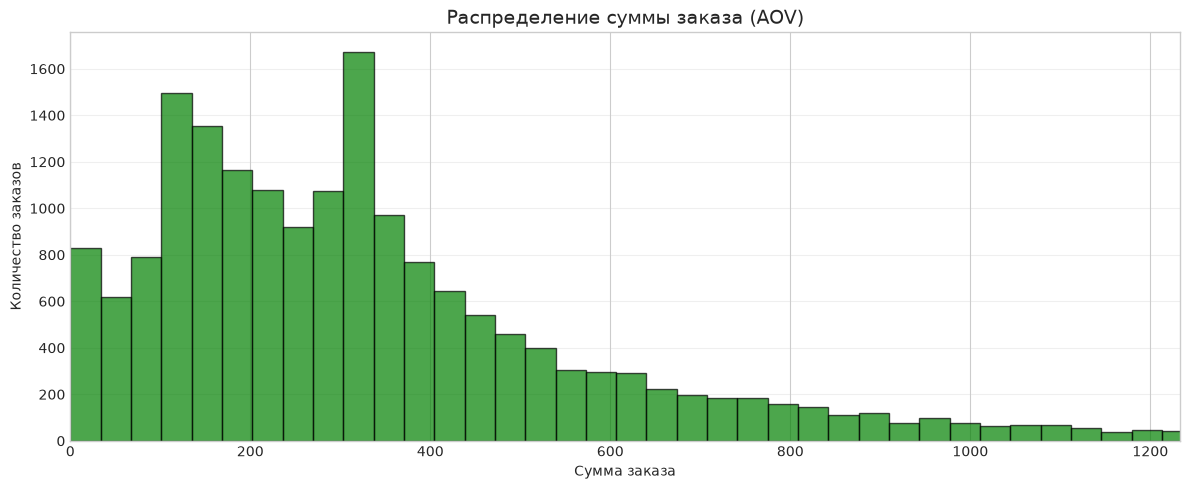

Средняя сумма заказа: 479.46
Медианная сумма заказа: 302.56


In [32]:
order_revenue = df_sales.groupby('InvoiceNo')['Revenue'].sum()

plt.figure(figsize=(12, 5))
order_revenue.hist(bins=5000, edgecolor='black', alpha=0.7, color='green')
plt.title('Распределение суммы заказа (AOV)', fontsize=14)
plt.xlabel('Сумма заказа')
plt.ylabel('Количество заказов')
plt.xlim(0, order_revenue.quantile(0.95))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Средняя сумма заказа: {order_revenue.mean():.2f}")
print(f"Медианная сумма заказа: {order_revenue.median():.2f}")

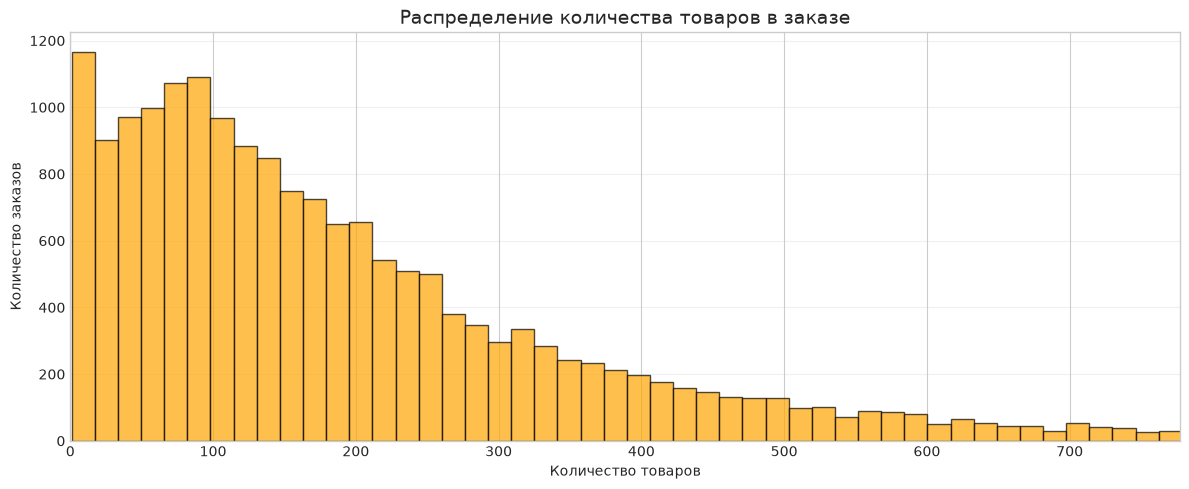

Среднее количество товаров в заказе: 278.69
Медиана: 154


In [33]:
items_per_order = df_sales.groupby('InvoiceNo')['Quantity'].sum()

plt.figure(figsize=(12, 5))
items_per_order.hist(bins=5000, edgecolor='black', alpha=0.7, color='orange')
plt.title('Распределение количества товаров в заказе', fontsize=14)
plt.xlabel('Количество товаров')
plt.ylabel('Количество заказов')
plt.xlim(0, items_per_order.quantile(0.95))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Среднее количество товаров в заказе: {items_per_order.mean():.2f}")
print(f"Медиана: {items_per_order.median():.0f}")

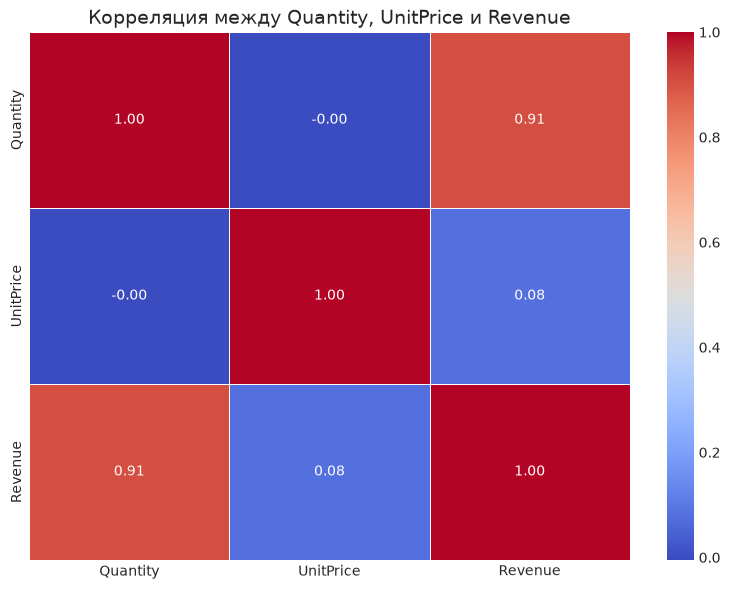

In [34]:
corr = df_sales[['Quantity', 'UnitPrice', 'Revenue']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция между Quantity, UnitPrice и Revenue', fontsize=14)
plt.tight_layout()
plt.show()

## Итоги исследовательского анализа данных (EDA)

### 1. Общие метрики
- **Валовая выручка:** 8 887 208.89
- **Количество заказов:** 18 536
- **Количество уникальных клиентов:** 4 339
- **Средний чек (AOV):** 479.46
- **Медианный чек:** 302.56
- **Средняя выручка на клиента:** 2 048.22

> **Вывод:** Большинство заказов – на сумму около 300, но редкие крупные покупки сильно увеличивают средний чек.

---

### 2. Сезонность
- Пик выручки приходится на **октябрь – декабрь** (предрождественский сезон).
- В январе наблюдается заметный спад, что типично для розничной торговли.
- В течение года есть небольшие колебания, но общий тренд стабильный.

> **Вывод:** Рекламные кампании стоит усиливать в октябре–ноябре, а в январе – использовать стимулирующие предложения для удержания клиентов.

---

### 3. География продаж
- **Великобритания** – основной рынок (более 80% выручки).
- Среди других стран лидируют:
  - Германия
  - Франция
  - Ирландия (EIRE)
  - Испания
- Всего представлено 37 стран.

> **Вывод:** Для расширения бизнеса стоит обратить внимание на Германию и Францию – они показывают стабильный спрос.

---

### 4. Товарная структура
- **Топ-3 товара** по выручке:
1) 23843 - PAPER CRAFT , LITTLE BIRDIE   
2) 22423 - REGENCY CAKESTAND 3 TIER   
3) 85123A - WHITE HANGING HEART T-LIGHT HOLDER
- Эти товары составляют значительную долю общей выручки – возможно, это популярные подарки или товары повседневного спроса.

> **Вывод:** Стоит проанализировать, почему эти товары лидируют (цена, сезонность, маркетинг)

---

### 5. Поведение покупателей
- Большинство заказов содержат **1–15 товаров**.
- Среднее количество товаров в заказе – `278.69`, медиана – `154`.
- Есть небольшое число заказов с очень большим количеством товаров (выбросы), которые увеличивают среднее.

> **Вывод:** Основная масса клиентов делает небольшие покупки.

---

### 6. Взаимосвязь показателей
- Корреляция между `Quantity` и `Revenue` – высокая (около `0.9`).
- Корреляция между `UnitPrice` и `Revenue` – слабая (около `0.08`).

> **Вывод:** Выручка определяется **количеством** проданных товаров, а не их ценой.

---

### 7. Общий вывод по EDA
Данные показывают здоровую структуру продаж с чёткой сезонностью и доминированием Великобритании. Основной драйвер выручки – количество товаров, а не цена. Выявлены ключевые товары и страны, на которых стоит сосредоточить маркетинговые усилия. Следующий этап – когортный анализ, который покажет, как клиенты возвращаются и как меняется их ценность со временем.

In [35]:
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')

In [36]:
df_sales['CohortMonth'] = df_sales.groupby('CustomerID')['InvoiceMonth'].transform('min')

In [37]:
df_sales['CohortIndex'] = (df_sales['InvoiceMonth'] - df_sales['CohortMonth']).apply(lambda x: x.n)

In [38]:
cohort_data = df_sales.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index(name='Customers')

In [39]:
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customers')

In [40]:
retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100

In [41]:
retention = retention.round(1)
print(retention)

CohortIndex     0     1     2     3     4     5     6     7     8     9   \
CohortMonth                                                                
2010-12      100.0  36.6  32.3  38.4  36.3  39.8  36.3  34.9  35.4  39.5   
2011-01      100.0  22.1  26.6  23.0  32.1  28.8  24.7  24.2  30.0  32.6   
2011-02      100.0  18.7  18.7  28.4  27.1  24.7  25.3  27.9  24.7  30.5   
2011-03      100.0  15.0  25.2  19.9  22.3  16.8  26.8  23.0  27.9   8.6   
2011-04      100.0  21.3  20.3  21.0  19.7  22.7  21.7  26.0   7.3   NaN   
2011-05      100.0  19.0  17.3  17.3  20.8  23.2  26.4   9.5   NaN   NaN   
2011-06      100.0  17.4  15.7  26.4  23.1  33.5   9.5   NaN   NaN   NaN   
2011-07      100.0  18.1  20.7  22.3  27.1  11.2   NaN   NaN   NaN   NaN   
2011-08      100.0  20.7  24.9  24.3  12.4   NaN   NaN   NaN   NaN   NaN   
2011-09      100.0  23.4  30.1  11.4   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10      100.0  24.0  11.5   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2011-11     

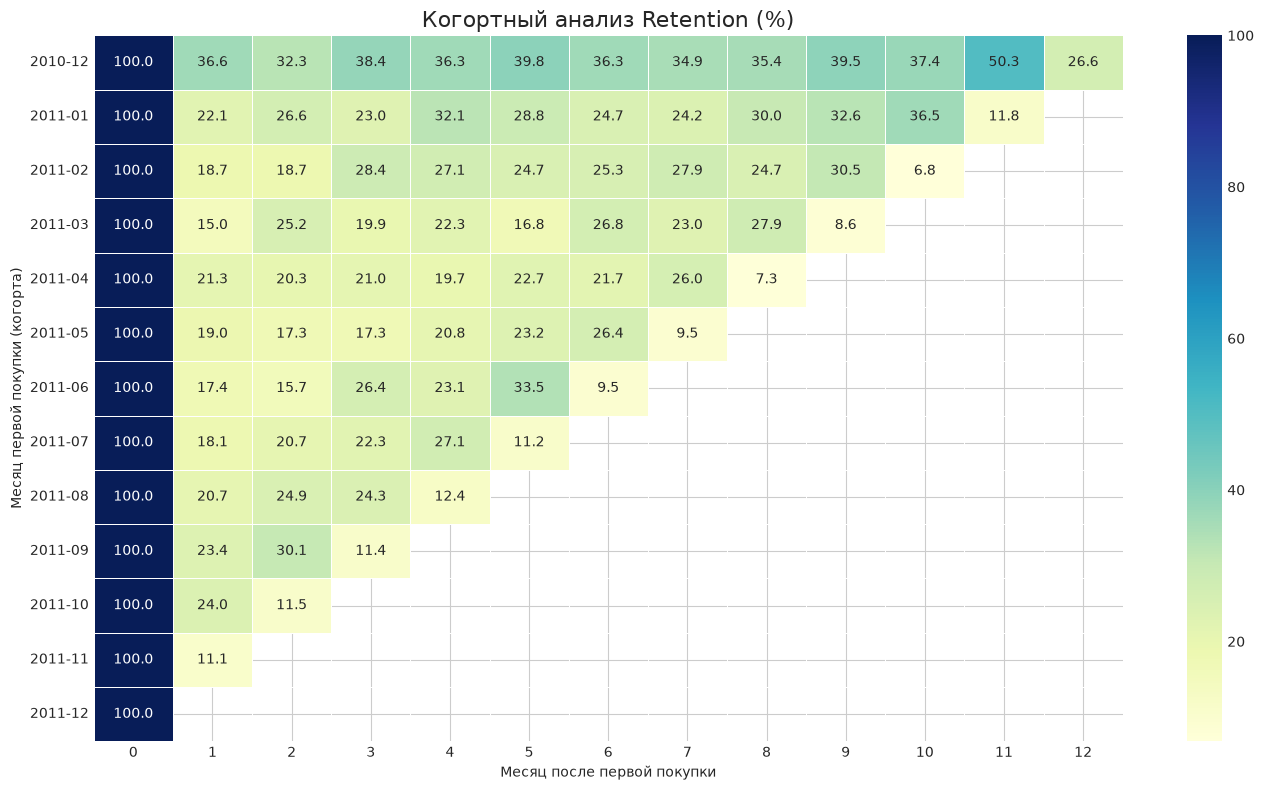

In [42]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Когортный анализ Retention (%)', fontsize=16)
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Месяц первой покупки (когорта)')
plt.tight_layout()
plt.show()

In [43]:
cohort_revenue = df_sales.groupby(['CohortMonth', 'CohortIndex']).agg({
    'Revenue': 'sum',
    'CustomerID': 'nunique'
}).reset_index()

cohort_revenue.columns = ['CohortMonth', 'CohortIndex', 'TotalRevenue', 'Customers']

cohort_revenue['LTV'] = cohort_revenue['TotalRevenue'] / cohort_revenue['Customers']

print("Первые строки таблицы LTV:")
print(cohort_revenue.head(10))
cohort_revenue.describe()

Первые строки таблицы LTV:
  CohortMonth  CohortIndex  TotalRevenue  Customers          LTV
0     2010-12            0     570422.73        885   644.545458
1     2010-12            1     275734.47        324   851.032315
2     2010-12            2     233390.47        286   816.050594
3     2010-12            3     302367.44        340   889.316000
4     2010-12            4     204034.38        321   635.621121
5     2010-12            5     336113.69        352   954.868438
6     2010-12            6     313668.16        321   977.159377
7     2010-12            7     310304.03        309  1004.220162
8     2010-12            8     331001.07        313  1057.511406
9     2010-12            9     471792.13        350  1347.977514


,CohortIndex,TotalRevenue,Customers,LTV
count,91.000000,91.000000,91.000000,91.000000
mean,4.000000,97661.636198,143.461538,633.834869
std,3.179797,121072.132753,140.656975,674.967966
min,0.000000,6040.700000,21.000000,287.652381
25%,1.000000,26528.965000,52.500000,410.822927
50%,3.000000,44487.650000,92.000000,498.111212
75%,6.000000,122530.955500,178.500000,668.390743
max,12.000000,570422.730000,885.000000,6636.452963


In [44]:
# Сводная таблица LTV
ltv_pivot = cohort_revenue.pivot(index='CohortMonth', columns='CohortIndex', values='LTV')
ltv_pivot = ltv_pivot.round(2)

print("Матрица LTV (средняя выручка на клиента за месяц):")
print(ltv_pivot)

Матрица LTV (средняя выручка на клиента за месяц):
CohortIndex      0       1       2        3       4       5       6        7   \
CohortMonth                                                                     
2010-12      644.55  851.03  816.05   889.32  635.62  954.87  977.16  1004.22   
2011-01      701.12  597.76  568.98   745.06  604.40  703.87  680.32   717.86   
2011-02      415.00  407.57  576.96   445.88  389.22  363.36  517.43   587.67   
2011-03      441.64  441.77  517.18   474.88  508.84  525.82  535.74   678.11   
2011-04      406.03  459.35  410.30   385.44  444.97  442.69  438.55   436.02   
2011-05      435.70  345.22  411.34   391.06  470.38  498.11  442.24  6636.45   
2011-06      559.57  350.92  371.17   482.79  476.25  525.08  354.05      NaN   
2011-07      392.87  346.76  397.14   414.09  375.62  287.65     NaN      NaN   
2011-08      471.01  598.11  844.25  1085.06  727.83     NaN     NaN      NaN   
2011-09      517.51  410.02  409.99   361.75     NaN     N

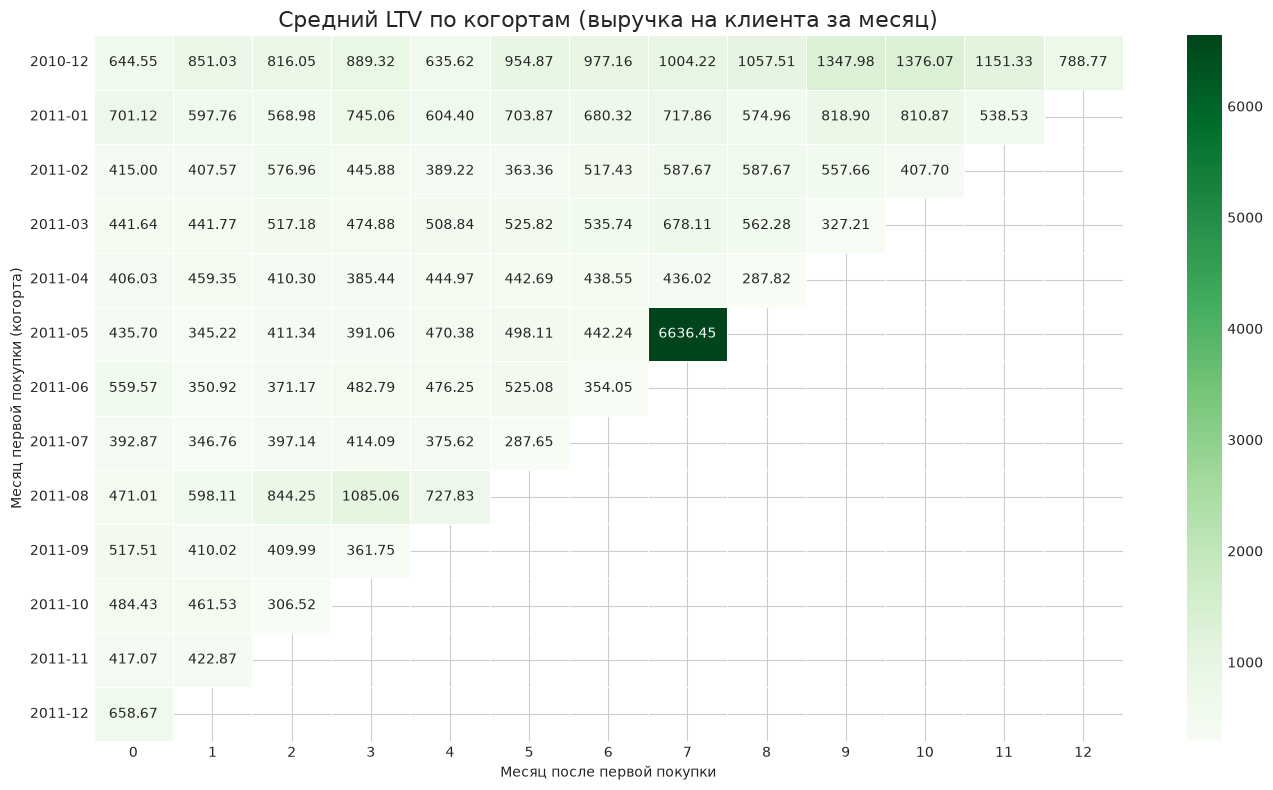

In [45]:
plt.figure(figsize=(14, 8))
sns.heatmap(ltv_pivot, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Средний LTV по когортам (выручка на клиента за месяц)', fontsize=16)
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Месяц первой покупки (когорта)')
plt.tight_layout()
plt.show()

In [46]:
# Кумулятивная сумма LTV по каждой когорте
cumulative_ltv = ltv_pivot.cumsum(axis=1).round(2)

print("Накопительный LTV (суммарно на клиента с начала жизни):")
print(cumulative_ltv)

Накопительный LTV (суммарно на клиента с начала жизни):
CohortIndex      0        1        2        3        4        5        6   \
CohortMonth                                                                 
2010-12      644.55  1495.58  2311.63  3200.95  3836.57  4791.44  5768.60   
2011-01      701.12  1298.88  1867.86  2612.92  3217.32  3921.19  4601.51   
2011-02      415.00   822.57  1399.53  1845.41  2234.63  2597.99  3115.42   
2011-03      441.64   883.41  1400.59  1875.47  2384.31  2910.13  3445.87   
2011-04      406.03   865.38  1275.68  1661.12  2106.09  2548.78  2987.33   
2011-05      435.70   780.92  1192.26  1583.32  2053.70  2551.81  2994.05   
2011-06      559.57   910.49  1281.66  1764.45  2240.70  2765.78  3119.83   
2011-07      392.87   739.63  1136.77  1550.86  1926.48  2214.13      NaN   
2011-08      471.01  1069.12  1913.37  2998.43  3726.26      NaN      NaN   
2011-09      517.51   927.53  1337.52  1699.27      NaN      NaN      NaN   
2011-10      484.43 

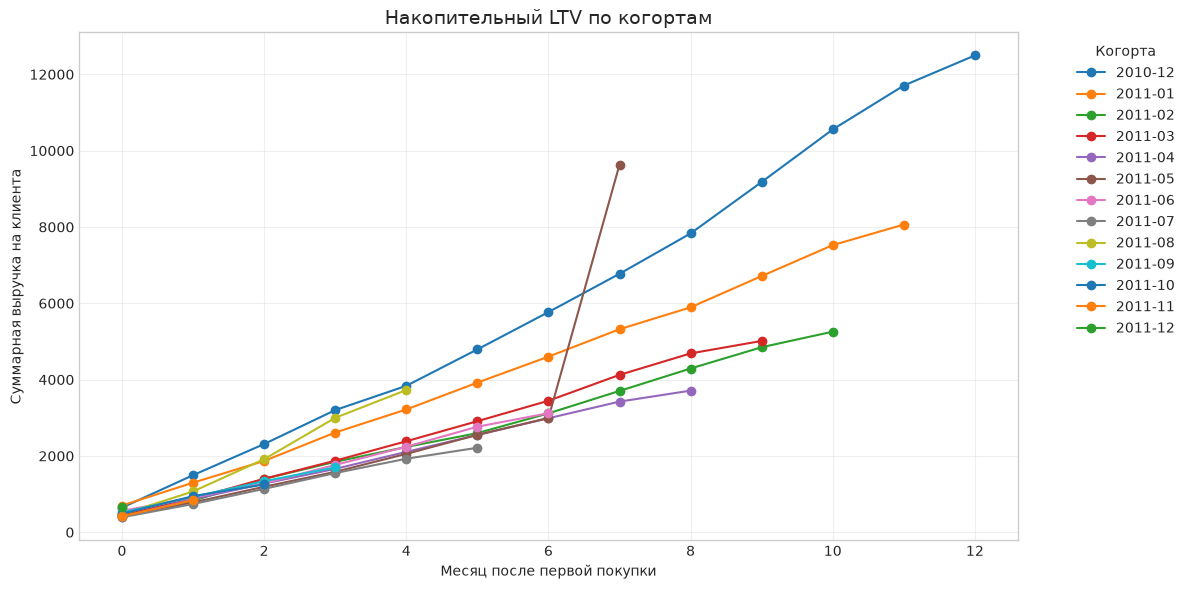

In [47]:
plt.figure(figsize=(12, 6))
# Для каждой когорты построим линию накопленного LTV
for cohort in cumulative_ltv.index:
    plt.plot(cumulative_ltv.columns, cumulative_ltv.loc[cohort], marker='o', label=str(cohort))

plt.title('Накопительный LTV по когортам', fontsize=14)
plt.xlabel('Месяц после первой покупки')
plt.ylabel('Суммарная выручка на клиента')
plt.legend(title='Когорта', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Когортный анализ Retention и LTV
---

### 1. Когортный анализ Retention

Retention показывает, какой процент клиентов из каждой когорты возвращается в магазин в последующие месяцы.

#### Ключевые результаты

| Метрика | Значение |
|---------|----------|
| **Лучшая когорта** | Декабрь 2010 (2010-12) |
| **Retention на 1-й месяц (2010-12)** | 36.6% |
| **Средний Retention на 1-й месяц** | ~22–23% |
| **Пиковый Retention (2010-12, 11-й месяц)** | 50.3% |
| **Худший старт** | Ноябрь 2011 (11.1%) |

#### Анализ

**1. Когорта-лидер: Декабрь 2010 (`2010-12`)**
- Стартовый Retention: **36.6%** – значительно выше среднего.
- Retention **никогда не опускается ниже 30%** на протяжении всех 12 месяцев наблюдения.
- Пик Retention достигает **50.3%** на 11-й месяц (ноябрь 2011). Это означает, что более половины клиентов, пришедших в декабре 2010, вернулись в магазин спустя почти год.

> **Интерпретация:** Клиенты, пришедшие в декабре, вероятно, совершали **подарочные покупки**. Их высокая лояльность объясняется тем, что они возвращаются за новыми подарками к следующему праздничному сезону. Пик в 50% через 11 месяцев подтверждает эту гипотезу.

**2. Средние когорты (Январь–Октябрь 2011)**
- Стартовый Retention колеблется от **15%** (март) до **24%** (октябрь).
- Retention нестабилен, так же наблюдается неестественное поведение: у многих когорт показатели на 6–9 месяце выше, чем на 2–3. Это может говорить о том, что клиенты возвращаются спустя полгода, вероятно, в связи с сезонными акциями (летние распродажи, подготовка к Новому году).


**3. Последний месяц для каждой когорты.**
- В ноябре 2011, а так же в последние месяцы для каждой когорты мы видим одинаково низкие значения. 
> **Гипотеза:** Низкий Retention может быть связан с недостатком данных за этот период.

---

### 2. Анализ LTV (Lifetime Value)

LTV показывает, сколько в среднем денег приносит один клиент из каждой когорты за каждый месяц жизни.

#### Ключевые результаты

| Метрика | Значение |
|---------|----------|
| **Лучшая когорта по LTV** | Декабрь 2010 (2010-12) |
| **Стартовый LTV (2010-12)** | 644.55 |
| **Пиковый LTV (2010-12, 10-й месяц)** | 1376.07 |
| **Накопленный LTV за 12 месяцев (2010-12)** | 12 494.48 |
| **Аномалия (2011-05, 7-й месяц)** | 6636.45 |

#### Анализ

**1. Лучшая когорта: Декабрь 2010 (`2010-12`)**
- Стартовый LTV: **644.55** – выше, чем у большинства когорт.
- LTV растёт почти каждый месяц, достигая пика **1376.07** на 10-й месяц.
- Накопленный LTV за 12 месяцев: **12 494.48**

> **Интерпретация:** Клиенты декабря 2010 не только часто возвращаются, но и **увеличивают свои траты** со временем. Это идеальный сегмент клиентов: они лояльны и готовы тратить больше.

**2. Когорта с аномалией: Май 2011 (`2011-05`)**
- На 7-й месяц (CohortIndex = 6) зафиксирован LTV = **6636.45**.
- Это явный выброс – скорее всего, один клиент (или очень маленькая группа) совершил экстремально крупную покупку.

> **Рекомендация:** Такие выбросы сильно искажают среднее значение. Для оценки "типичного" клиента следует использовать **медиану**, а не среднее.

**3. Когорта с неожиданным ростом: Август 2011 (`2011-08`)**
- LTV растёт с **471** (месяц 0) до **1085** (месяц 3) и **727** (месяц 4).
- Клиенты этой когорты совершали крупные покупки через несколько месяцев после первой.

> **Гипотеза:** Возможно, это клиенты, которые пришли в августе (перед осенним сезоном) и затем делали крупные закупки в сентябре–октябре.

**4. Слабые когорты: Февраль, Апрель, Июль 2011**
- Стартовый LTV около **400**, накопленный LTV за 6 месяцев – около **3000**.
- Клиенты тратят мало и редко возвращаются.

> **Рекомендация:** Возможно, эти когорты были привлечены через менее эффективные каналы (например, массовые скидки).

---

### 3. Связь Retention и LTV

| Когорта | Retention (1-й месяц) | Накопленный LTV (за 6 мес.) | Характеристика |
|---------|------------------------|-----------------------------|----------------|
| **2010-12** | 36.6% | 5 768.60 |  Высокий Retention + высокий LTV → **Идеальные клиенты** |
| **2011-08** | 20.7% | ~3 700 |  Средний Retention + высокий LTV → **Редкие, но крупные покупки** |
| **2011-05** | 19.0% | 2 994.05 (с выбросом) |  Низкий Retention + аномальный LTV → **Нестабильная когорта** |
| **2011-02** | 18.7% | 3 115.42 |  Низкий Retention + низкий LTV → **Слабая когорта** |

**Главный вывод:**  
Retention и LTV не всегда коррелируют. Клиенты могут возвращаться редко, но тратить много (как в когорте `2011-08`), и наоборот.

---

### 4. Общие выводы 

1. **Декабрь 2010 – идеальная когорта:**  
   Клиенты, привлечённые в декабре, показывают исключительную лояльность (Retention 36%+, пик 50%) и высокую денежную ценность (LTV растёт до 1376, накопленный LTV за год – 12 494). Это связано с сезонностью (подарочные покупки) и, вероятно, качеством трафика.

2. **Сезонный паттерн:**  
   У многих когорт наблюдается "эффект пробуждения" – клиенты возвращаются через 6–9 месяцев, что совпадает с сезонными акциями (летние распродажи, подготовка к Новому году).

3. **Низкие значения последних месяцев анализа:**  
   Связано с недостатком данных.

4. **Выбросы искажают средние:**  
   Аномалия в когорте мая 2011 (LTV = 6636) показывает, что для оценки "типичного" клиента нужно использовать медиану, а не среднее.
